In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [87]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import load_merged_samples, load_merged_cns, load_COSMIC, save_cns_fig
from cns.process.aggregation import aggregate_by_breaks, group_samples, add_total_cn
from cns.process.breakpoints import get_breaks_from_cns, make_breaks
from cns.utils.assemblies import hg19
from cns.utils.cytobands import hg19_cytobands
from cns.display.plot import fig_lines

In [57]:
cosmic_genes = load_COSMIC()
gene_start, gene_end = [(g_start, g_end) for g_start, g_end, g_name in cosmic_genes["chr3"] if g_name == "SOX2"][0]
arm_start = [band[2] for band in hg19_cytobands if band[0] == "chr3" and band[4] == 'acen'][1]
arm_end = hg19.chr_lens['chr3']

In [58]:
samples = load_merged_samples().query("type == 'LUSC'")
cns = load_merged_cns(samples)

In [59]:
data_chr3 = cns.query("chrom == 'chr3'")
data_breaks_chrom = get_breaks_from_cns(data_chr3)["chr3"]
breaks_arm = [arm_start] + [breakpoint for breakpoint in data_breaks_chrom if arm_start < breakpoint < arm_end] + [arm_end]
len(breaks_arm)

4099

In [60]:
aggregated_data = aggregate_by_breaks(data_chr3, {"chr3" : breaks_arm}, print_info=True)

Aggregated into 4085706 CNS.                                        


In [101]:
groups = add_total_cn(group_samples(aggregated_data))
groups["ampl"] = groups["total_cn"]

In [143]:
start_cn = groups["ampl"].iloc[0]
end_cn = groups["ampl"].iloc[-1]
gene_cn = groups.query("@gene_start < end and @gene_end > start")["ampl"].min()
diff_cn = gene_cn - start_cn
end_prob = (end_cn - diff_cn) / diff_cn

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='position on chr3', ylabel='mean CN per segment'>)

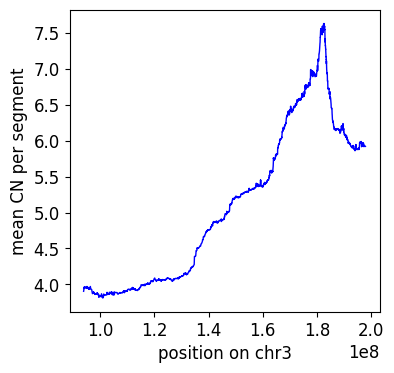

In [134]:
fig_lines(groups, chrom="chr3", column="ampl")

In [144]:
# Initialize a list to store the ranges
random.seed(0)
ranges_inside = []
ranges_tail = []
sim_segs = 1000

# Repeat until 8 ranges are sampled
while len(ranges_inside) < sim_segs:    
    rand_start = random.randint(arm_start, arm_end)
    rand_end = random.randint(arm_start, arm_end)

    if rand_start > rand_end:
        rand_start, rand_end = rand_end, rand_start

    # Check if the range contains gene_start and gene_end
    if rand_start <= gene_start and rand_end >= gene_end:
        # If it does, add it to the list
        ranges_inside.append((rand_start, rand_end))

while len(ranges_tail) < sim_segs:    
    rand_start = random.randint(arm_start, arm_end)

    # Check if the range contains gene_start and gene_end
    if rand_start <= gene_start and rand_end >= gene_end:
        # If it does, add it to the list
        ranges_tail.append((rand_start, rand_end))

In [145]:
breaks = np.array(ranges_inside).flatten()
breaks.sort()
split_ranges = []

for r_start, r_end in ranges_inside:
    current_start = r_start

    for brk in breaks:
        if r_start < brk < r_end:
            split_ranges.append((current_start, brk))
            current_start = brk

    split_ranges.append((current_start, r_end))

In [141]:
# Count the occurrences of each pair
counts = pd.Series(split_ranges).value_counts().reset_index()

# Rename the columns
counts.columns = ['range', 'CN']

# Split the range into start and end
counts[['start', 'end']] = pd.DataFrame(counts['range'].tolist(), index=counts.index)

# Drop the 'range' column
counts = counts.drop('range', axis=1)

# Reorder the columns
counts = counts[['start', 'end', 'CN']].sort_values(by=['start'], ignore_index=True)
counts["CN"] = counts["CN"] / sim_segs * diff_cn + start_cn
counts.head()

,start,end,CN
0,93918022,93969041,3.907363
1,93969041,94035934,3.911015
2,94035934,94040852,3.914667
3,94040852,94057399,3.918319
4,94057399,94074962,3.921971


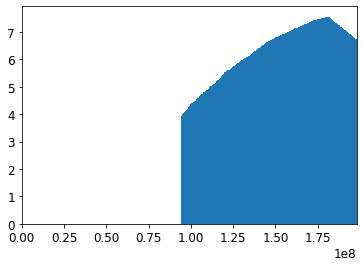

In [142]:

# Calculate the widths of the bars
widths = counts['end'] - counts['start']

# Create a bar plot
plt.bar(x=counts['start'], height=counts['CN'], width=widths, align='edge')

# Set the x-axis start to 0
plt.xlim(0, max(counts['end']))

# Display the plot
plt.show()

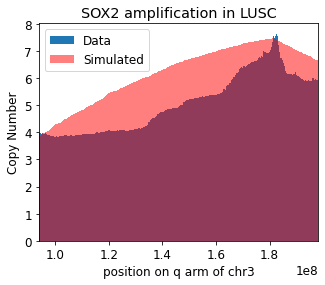

In [120]:
# bar plot groups 
fig, ax = plt.subplots(figsize=(5, 4))

# double font size
plt.rcParams.update({'font.size': 12})

# Create a bar plot
plt.bar(x=groups['start'], height=groups['total_cn'], width=(groups['end'] - groups['start']), align='edge')

plt.bar(x=counts['start'], height=counts['CN'], width=widths, align='edge', alpha=0.5, color='red')


# Set the x-axis start to 0
plt.xlim(arm_start, max(counts['end']))

# label
plt.xlabel("position on q arm of chr3")
plt.ylabel("Copy Number")
plt.title("SOX2 amplification in LUSC")

# add legend
plt.legend(["Data", "Simulated"])